# Import

In [65]:
from pathlib import Path
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
from scipy.stats import f_oneway, kruskal

sns.set(style="whitegrid")

# Load cleaned CSVs

In [66]:
BASE_DIR = Path.cwd().parent
DATA_DIR = BASE_DIR / "data"

file_paths = {
    "Benin": DATA_DIR / "benin-malanville_clean.csv",
    "Sierraleone": DATA_DIR / "sierraleone-bumbuna_clean.csv",
    "Togo": DATA_DIR / "togo-dapaong_qc_clean.csv"
}

dfs = {country: pd.read_csv(path) for country, path in file_paths.items()}

# Add a 'Country' column to each for plotting/aggregation

In [67]:
for country, df_country in dfs.items():
    df_country['Country'] = country

# Combine into a single DataFrame

In [68]:
df = pd.concat(dfs.values(), ignore_index=True)

# Metric comparison: Boxplots

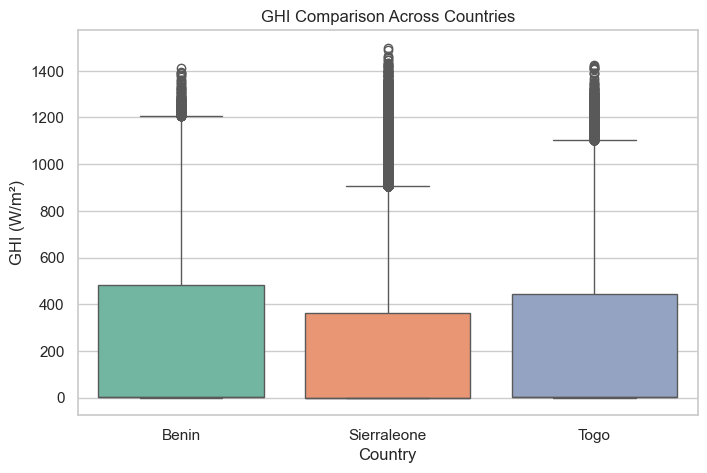

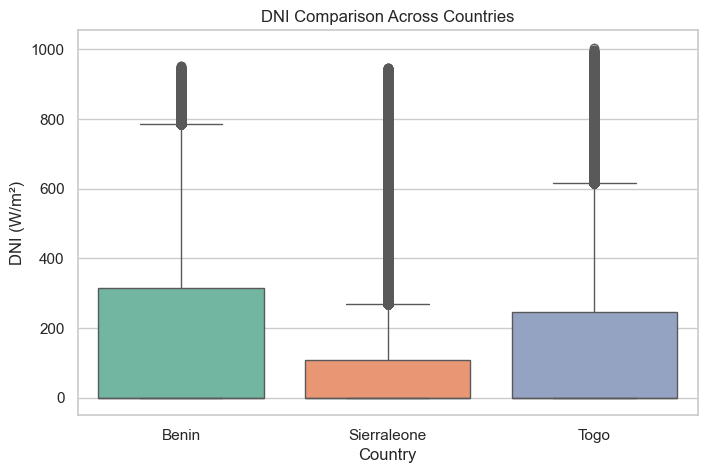

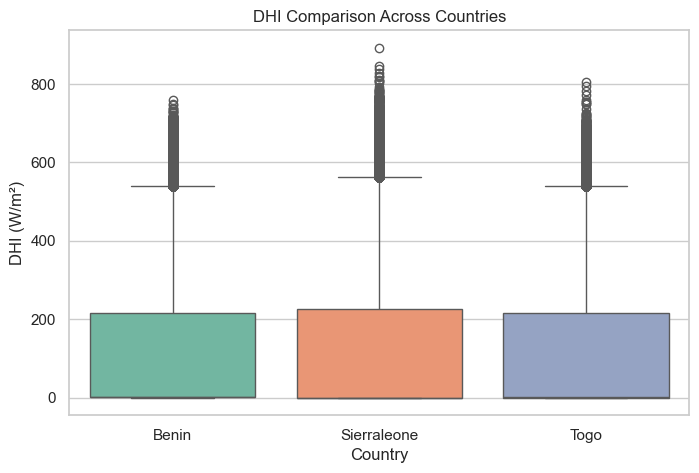

In [69]:
metrics = ['GHI', 'DNI', 'DHI']

for metric in metrics:
    plt.figure(figsize=(8,5))
    
    # Correct way in Seaborn 0.14+:
    # Assign x='Country' also as hue, but remove legend immediately
    ax = sns.boxplot(
        x='Country', y=metric, hue='Country', data=df, palette='Set2', dodge=False
    )
    
    plt.title(f'{metric} Comparison Across Countries')
    plt.ylabel(f'{metric} (W/m²)')
    
    # Remove redundant legend safely
    if ax.get_legend() is not None:
        ax.get_legend().remove()
    
    plt.show()

# Summary Table

In [70]:
summary_table = df.groupby('Country')[metrics].agg(['mean', 'median', 'std'])
summary_table

GHI                            DNI                     \
                   mean median         std        mean median         std   
Country                                                                     
Benin        242.845283    1.8  329.452613  167.389357   -0.1  261.581151   
Sierraleone  204.555828    0.3  296.684885  116.473055   -0.1  218.601012   
Togo         232.747150    2.1  320.952070  151.258469    0.0  250.956962   

                    DHI                     
                   mean median         std  
Country                                     
Benin        117.782020    1.6  156.878357  
Sierraleone  116.223615   -0.1  157.057943  
Togo         116.444352    2.5  156.520714

# Statistical Testing

## Prepare GHI data by country

In [71]:

ghi_data = [df_country['GHI'] for df_country in dfs.values()]


## One-way ANOVA

In [72]:
anova_stat, anova_p = f_oneway(*ghi_data)
print(f"ANOVA: F={anova_stat:.2f}, p={anova_p:.4f}")

ANOVA: F=2072.78, p=0.0000


### Key Observations

- **Benin leads in overall solar potential:** It has the highest average GHI (242.85 W/m²) and DNI (167.39 W/m²), but also shows the greatest variability in GHI and DNI, indicating that solar radiation is strong but less consistent.  

- **Togo shows consistent direct sunlight:** While its average GHI (232.75 W/m²) is slightly lower than Benin, it has the highest median GHI (2.1 W/m²) and moderate variability, suggesting more reliable daily solar potential.  

- **Sierra Leone has comparable diffuse radiation:** Despite having the lowest average GHI (204.56 W/m²) and DNI (116.47 W/m²), its DHI is similar to the other countries (~157 W/m²), indicating that solar PV systems could still perform reasonably well under cloudy conditions.  

# Visual Summary: Average GHI Ranking by Country

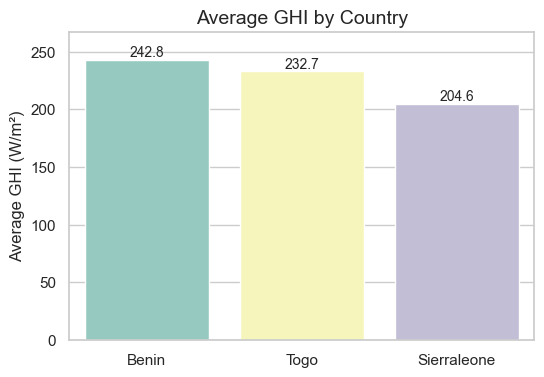

In [73]:
avg_ghi = df.groupby('Country')['GHI'].mean().sort_values(ascending=False)

plt.figure(figsize=(6,4))
sns.barplot(
    x=avg_ghi.index,
    y=avg_ghi.values,
    palette='Set3',
    hue=avg_ghi.index,
    dodge=False,          
    legend=False          
)
plt.title('Average GHI by Country', fontsize=14)
plt.ylabel('Average GHI (W/m²)', fontsize=12)
plt.xlabel('')
plt.ylim(0, max(avg_ghi.values)*1.1)  # optional: add 10% headroom
for i, v in enumerate(avg_ghi.values):
    plt.text(i, v + 3, f"{v:.1f}", ha='center', fontsize=10)  # display values above bars
plt.show()